# EDA — Fraud_Data.csv
**Adey Innovations Inc. | Fraud Detection | Week 5 & 6**

**Objective:** Explore the e-commerce transaction dataset to understand structure, distributions, class imbalance, and patterns that distinguish fraudulent from legitimate transactions.

---

## 0. Setup

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

BLUE  = '#2E75B6'
CORAL = '#E95D4F'
GREEN = '#70AD47'

DATA_PATH = '../data/raw/Fraud_Data.csv'
IP_PATH   = '../data/raw/IpAddress_to_Country.csv'
print('Setup complete.')

Setup complete.


---
## 1. Dataset Overview

In [31]:
df = pd.read_csv(DATA_PATH)
df['signup_time']   = pd.to_datetime(df['signup_time'])
df['purchase_time'] = pd.to_datetime(df['purchase_time'])

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Date range: {df["purchase_time"].min().date()} → {df["purchase_time"].max().date()}')
print(f'Unique users:   {df["user_id"].nunique():,}')
print(f'Unique devices: {df["device_id"].nunique():,}')
print()
df.head()

Shape: 151,112 rows × 11 columns
Date range: 2015-01-01 → 2015-12-16
Unique users:   151,112
Unique devices: 137,956



,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [32]:
print('Data types:')
print(df.dtypes)
print()
print('Missing values:')
print(df.isnull().sum())

Data types:
user_id                    int64
signup_time       datetime64[us]
purchase_time     datetime64[us]
purchase_value             int64
device_id                    str
source                       str
browser                      str
sex                          str
age                        int64
ip_address               float64
class                      int64
dtype: object

Missing values:
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64


In [33]:
# Cardinality table
card = pd.DataFrame({
    'Dtype':    df.dtypes,
    'Unique':   df.nunique(),
    'Missing':  df.isnull().sum(),
    'Miss%':    (df.isnull().sum()/len(df)*100).round(2)
})
print(card.to_string())

                         Dtype  Unique  Missing  Miss%
user_id                  int64  151112        0    0.0
signup_time     datetime64[us]  151112        0    0.0
purchase_time   datetime64[us]  150679        0    0.0
purchase_value           int64     122        0    0.0
device_id                  str  137956        0    0.0
source                     str       3        0    0.0
browser                    str       5        0    0.0
sex                        str       2        0    0.0
age                      int64      58        0    0.0
ip_address             float64  143512        0    0.0
class                    int64       2        0    0.0


---
## 2. Class Imbalance

Class distribution:
  Legitimate (0): 136,961  (90.64%)
  Fraud (1): 14,151  (9.36%)


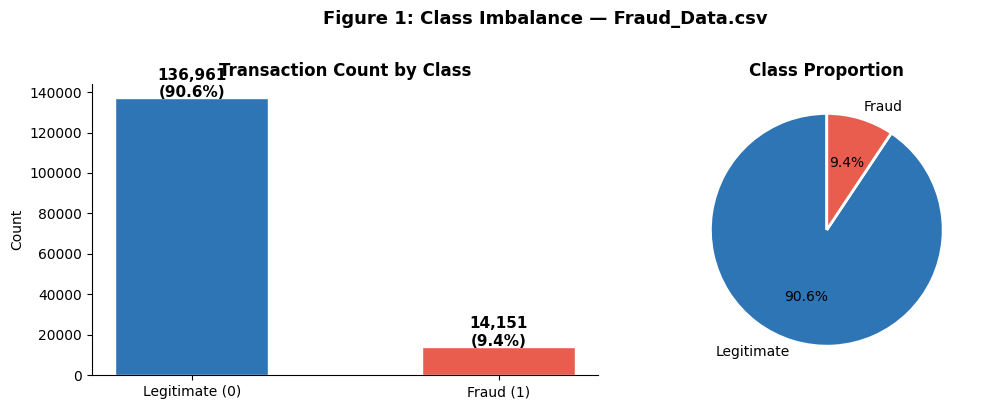

In [34]:
counts = df['class'].value_counts()
pcts   = df['class'].value_counts(normalize=True)*100

print('Class distribution:')
for k in counts.index:
    label = 'Fraud' if k==1 else 'Legitimate'
    print(f'  {label} ({k}): {counts[k]:,}  ({pcts[k]:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['Legitimate (0)', 'Fraud (1)'],
            [counts[0], counts[1]],
            color=[BLUE, CORAL], width=0.5, edgecolor='white')
for i, (k, v) in enumerate(counts.items()):
    axes[0].text(i, v+500, f'{v:,}\n({pcts[k]:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Transaction Count by Class', fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie([counts[0], counts[1]],
            labels=['Legitimate', 'Fraud'],
            colors=[BLUE, CORAL],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontweight='bold')

plt.suptitle('Figure 1: Class Imbalance — Fraud_Data.csv', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/figures/fig1_class_imbalance_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Univariate Analysis

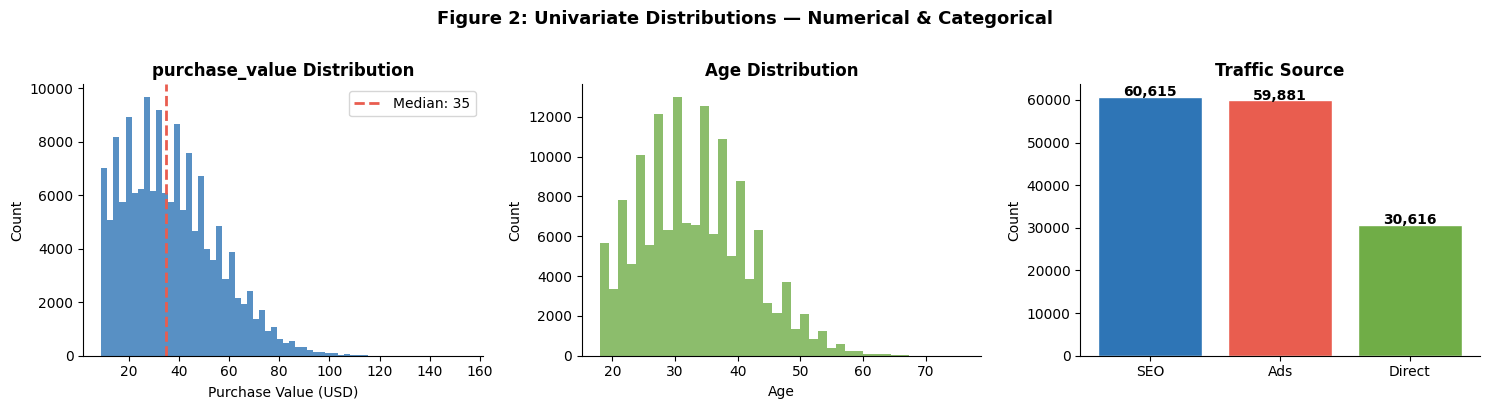

Summary stats:
       purchase_value        age
count       151112.00  151112.00
mean            36.94      33.14
std             18.32       8.62
min              9.00      18.00
25%             22.00      27.00
50%             35.00      33.00
75%             49.00      39.00
max            154.00      76.00


In [35]:
# purchase_value distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['purchase_value'], bins=60, color=BLUE, alpha=0.8, edgecolor='none')
axes[0].axvline(df['purchase_value'].median(), color=CORAL, lw=2, linestyle='--',
                label=f"Median: {df['purchase_value'].median():.0f}")
axes[0].set_title('purchase_value Distribution', fontweight='bold')
axes[0].set_xlabel('Purchase Value (USD)'); axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(df['age'], bins=40, color=GREEN, alpha=0.8, edgecolor='none')
axes[1].set_title('Age Distribution', fontweight='bold')
axes[1].set_xlabel('Age'); axes[1].set_ylabel('Count')

src_counts = df['source'].value_counts()
axes[2].bar(src_counts.index, src_counts.values, color=[BLUE, CORAL, GREEN], edgecolor='white')
for i, v in enumerate(src_counts.values):
    axes[2].text(i, v+200, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
axes[2].set_title('Traffic Source', fontweight='bold')
axes[2].set_ylabel('Count')

plt.suptitle('Figure 2: Univariate Distributions — Numerical & Categorical', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/figures/fig2_univariate_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

print('Summary stats:')
print(df[['purchase_value','age']].describe().round(2))

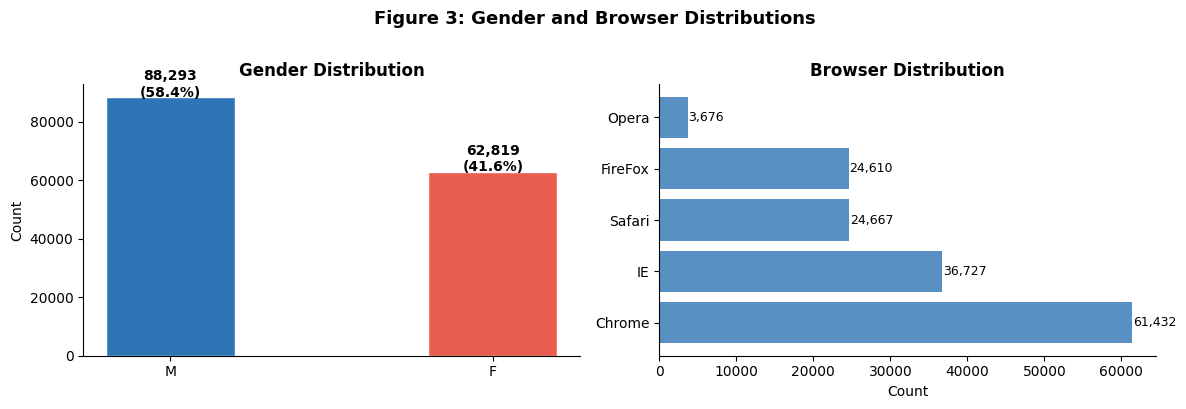

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sex_counts = df['sex'].value_counts()
axes[0].bar(sex_counts.index, sex_counts.values, color=[BLUE, CORAL], width=0.4, edgecolor='white')
for i, v in enumerate(sex_counts.values):
    axes[0].text(i, v+200, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Gender Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

browser_counts = df['browser'].value_counts()
axes[1].barh(browser_counts.index, browser_counts.values, color=BLUE, alpha=0.8, edgecolor='none')
for i, v in enumerate(browser_counts.values):
    axes[1].text(v+100, i, f'{v:,}', va='center', fontsize=9)
axes[1].set_title('Browser Distribution', fontweight='bold')
axes[1].set_xlabel('Count')

plt.suptitle('Figure 3: Gender and Browser Distributions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/figures/fig3_categorical_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Bivariate Analysis — Fraud vs Legitimate

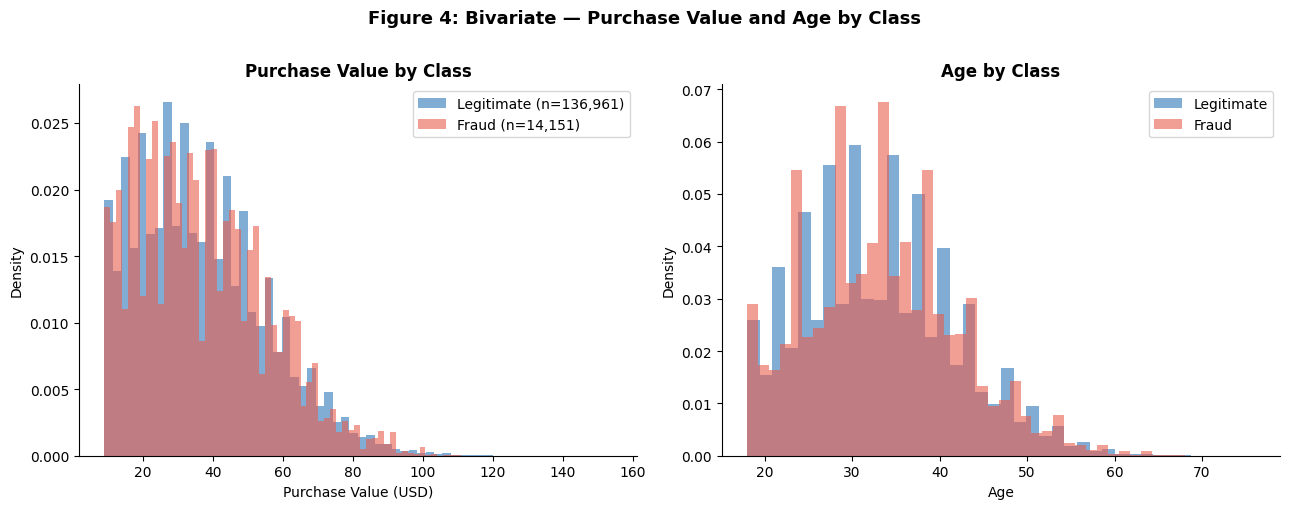

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for cls, color, label in [(0, BLUE, 'Legitimate'), (1, CORAL, 'Fraud')]:
    subset = df[df['class']==cls]['purchase_value']
    axes[0].hist(subset, bins=60, alpha=0.6, color=color, label=f'{label} (n={len(subset):,})',
                 density=True, edgecolor='none')
axes[0].set_title('Purchase Value by Class', fontweight='bold')
axes[0].set_xlabel('Purchase Value (USD)')
axes[0].set_ylabel('Density')
axes[0].legend()

for cls, color, label in [(0, BLUE, 'Legitimate'), (1, CORAL, 'Fraud')]:
    subset = df[df['class']==cls]['age']
    axes[1].hist(subset, bins=40, alpha=0.6, color=color, label=f'{label}',
                 density=True, edgecolor='none')
axes[1].set_title('Age by Class', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Figure 4: Bivariate — Purchase Value and Age by Class', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/figures/fig4_bivariate_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

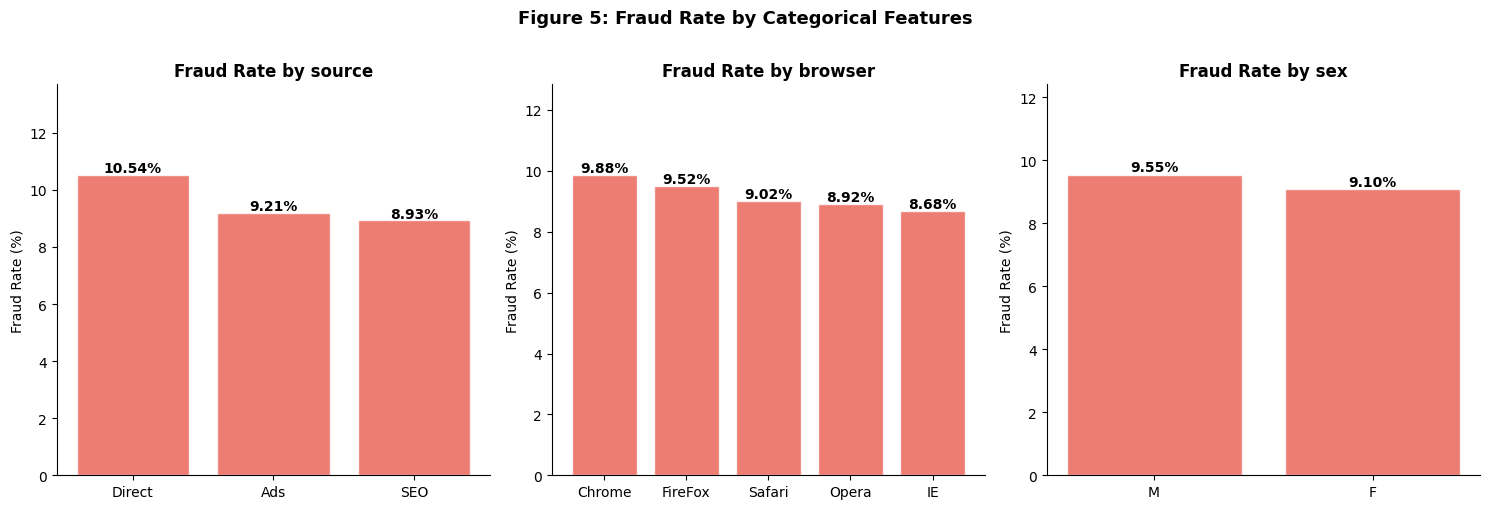

In [38]:
# Fraud rate by categorical features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['source', 'browser', 'sex']):
    fraud_rate = df.groupby(col)['class'].mean() * 100
    fraud_rate = fraud_rate.sort_values(ascending=False)
    ax.bar(fraud_rate.index, fraud_rate.values, color=CORAL, alpha=0.8, edgecolor='white')
    for i, v in enumerate(fraud_rate.values):
        ax.text(i, v+0.1, f'{v:.2f}%', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(f'Fraud Rate by {col}', fontweight='bold')
    ax.set_ylabel('Fraud Rate (%)')
    ax.set_ylim(0, fraud_rate.max() * 1.3)

plt.suptitle('Figure 5: Fraud Rate by Categorical Features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/figures/fig5_fraud_rate_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Time-Based Analysis

2026-06-08 06:20:02,143 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-08 06:20:02,147 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


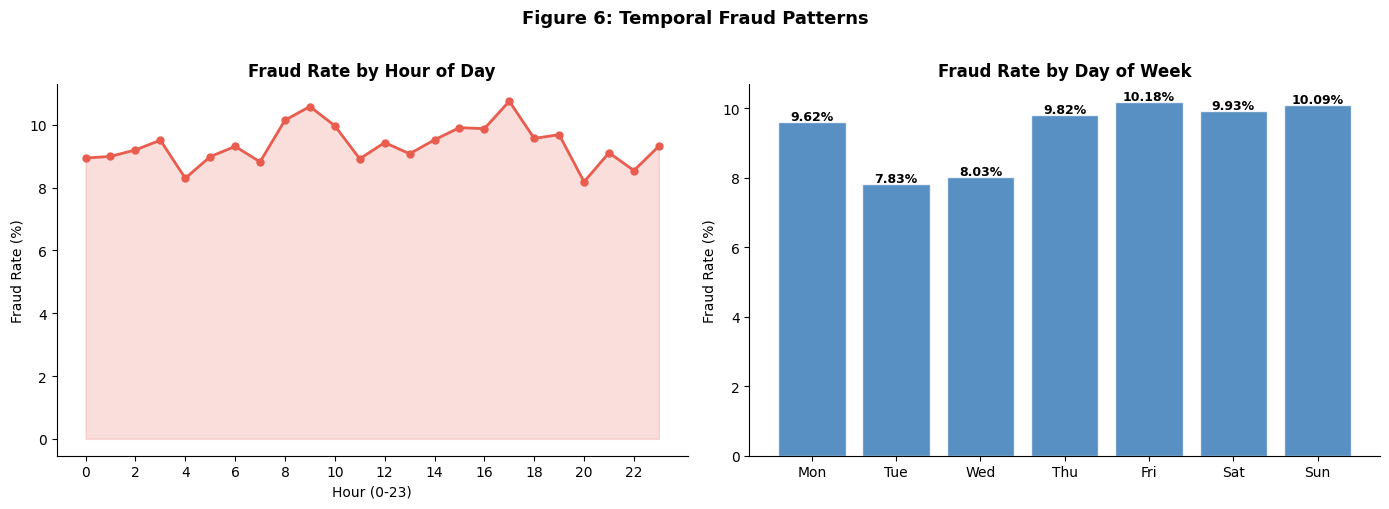

In [39]:
df['hour_of_day'] = df['purchase_time'].dt.hour
df['day_of_week'] = df['purchase_time'].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud rate by hour
hour_fraud = df.groupby('hour_of_day')['class'].mean() * 100
axes[0].plot(hour_fraud.index, hour_fraud.values, color=CORAL, lw=2, marker='o', markersize=5)
axes[0].fill_between(hour_fraud.index, hour_fraud.values, alpha=0.2, color=CORAL)
axes[0].set_title('Fraud Rate by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_xticks(range(0, 24, 2))

# Fraud rate by day of week
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_fraud = df.groupby('day_of_week')['class'].mean() * 100
axes[1].bar([day_labels[i] for i in day_fraud.index], day_fraud.values,
            color=BLUE, alpha=0.8, edgecolor='white')
for i, v in enumerate(day_fraud.values):
    axes[1].text(i, v+0.05, f'{v:.2f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Fraud Rate by Day of Week', fontweight='bold')
axes[1].set_ylabel('Fraud Rate (%)')

plt.suptitle('Figure 6: Temporal Fraud Patterns', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/figures/fig6_temporal_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. time_since_signup Analysis

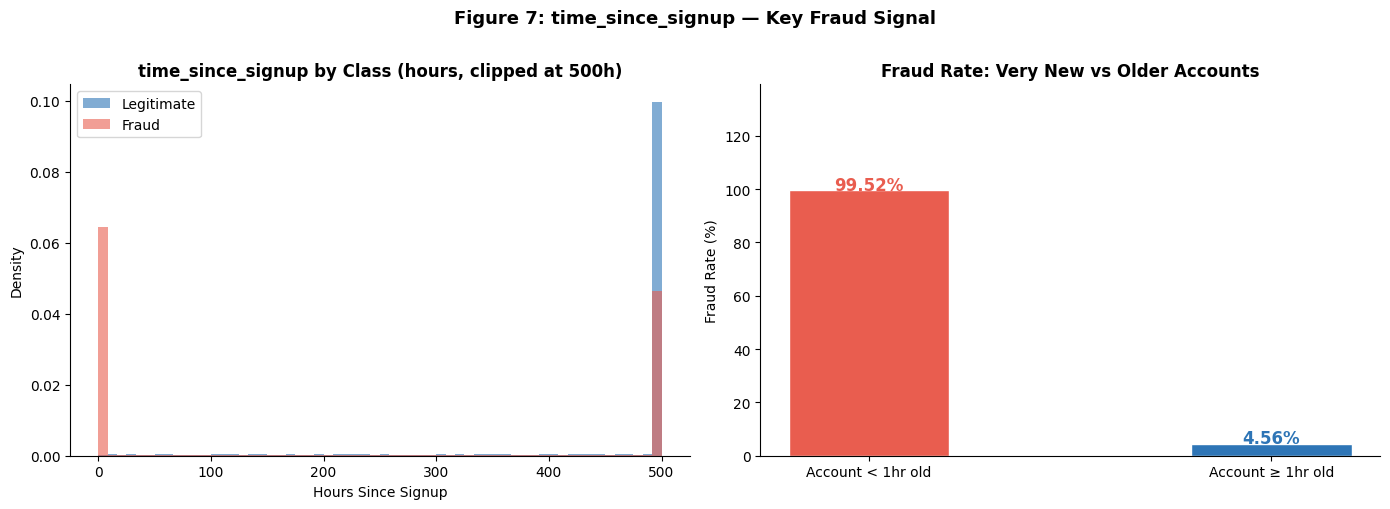

Fraud rate for accounts < 1 hour old: 99.52%
Fraud rate for accounts ≥ 1 hour old: 4.56%


In [40]:
df['time_since_signup'] = (df['purchase_time'] - df['signup_time']).dt.total_seconds()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution by class
for cls, color, label in [(0, BLUE, 'Legitimate'), (1, CORAL, 'Fraud')]:
    subset = df[df['class']==cls]['time_since_signup'] / 3600  # hours
    axes[0].hist(subset.clip(0, 500), bins=60, alpha=0.6,
                 color=color, density=True, label=label, edgecolor='none')
axes[0].set_title('time_since_signup by Class (hours, clipped at 500h)', fontweight='bold')
axes[0].set_xlabel('Hours Since Signup')
axes[0].set_ylabel('Density')
axes[0].legend()

# Very new accounts (< 1 hour)
df['very_new_account'] = (df['time_since_signup'] < 3600).astype(int)
new_fraud  = df[df['very_new_account']==1]['class'].mean()*100
old_fraud  = df[df['very_new_account']==0]['class'].mean()*100
axes[1].bar(['Account < 1hr old', 'Account ≥ 1hr old'],
            [new_fraud, old_fraud],
            color=[CORAL, BLUE], width=0.4, edgecolor='white')
axes[1].text(0, new_fraud+0.2, f'{new_fraud:.2f}%', ha='center', fontsize=12, fontweight='bold', color=CORAL)
axes[1].text(1, old_fraud+0.2, f'{old_fraud:.2f}%', ha='center', fontsize=12, fontweight='bold', color=BLUE)
axes[1].set_title('Fraud Rate: Very New vs Older Accounts', fontweight='bold')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_ylim(0, new_fraud * 1.4)

plt.suptitle('Figure 7: time_since_signup — Key Fraud Signal', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/figures/fig7_time_since_signup.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Fraud rate for accounts < 1 hour old: {new_fraud:.2f}%')
print(f'Fraud rate for accounts ≥ 1 hour old: {old_fraud:.2f}%')

---
## 7. Geolocation — IP to Country

2026-06-08 06:20:04,820 | INFO | Converting IP addresses to integers ...
2026-06-08 06:20:05,035 | INFO | Geolocation: 129146/151112 matched (85.5%), 182 unique countries


Unique countries identified: 182
Top 15 countries by transaction count:
country
United States         58049
Unknown               21966
China                 12038
Japan                  7306
United Kingdom         4490
Korea Republic of      4162
Germany                3646
France                 3161
Canada                 2975
Brazil                 2961
Italy                  1944
Australia              1844
Netherlands            1680
Russian Federation     1616
India                  1310
Name: count, dtype: int64


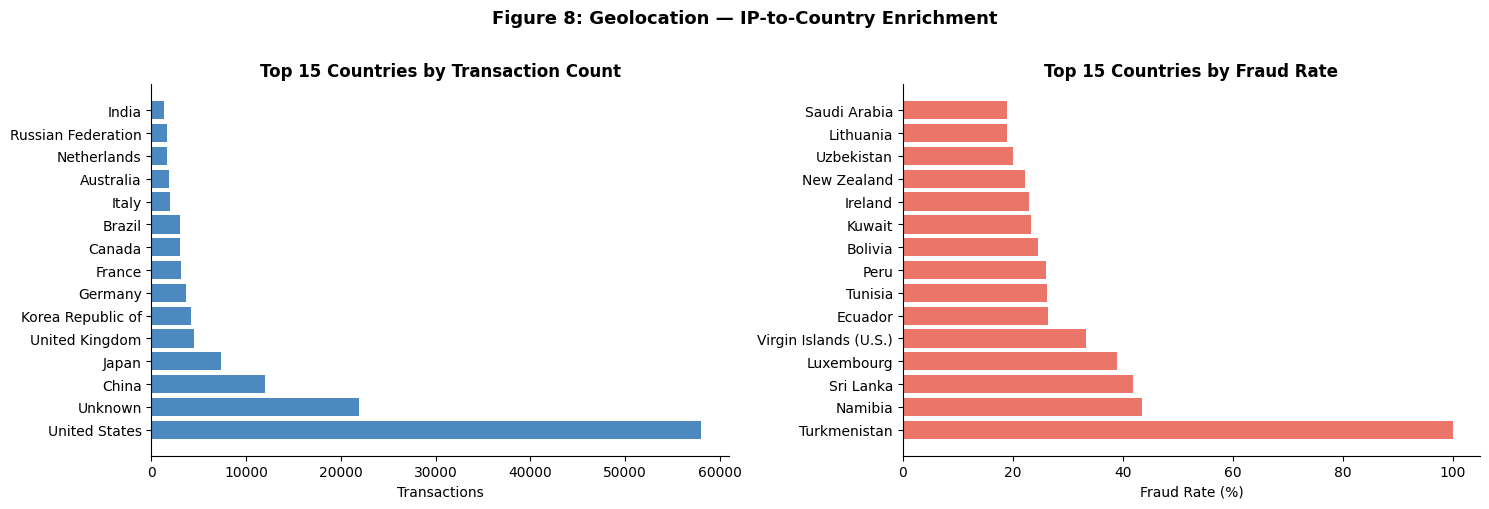

In [41]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))
from data_preprocessing import enrich_with_country

ip_df = pd.read_csv(IP_PATH)
df_geo = enrich_with_country(df, ip_df)

print(f'Unique countries identified: {df_geo["country"].nunique()}')
print('Top 15 countries by transaction count:')
print(df_geo['country'].value_counts().head(15))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top15 = df_geo['country'].value_counts().head(15)
axes[0].barh(top15.index, top15.values, color=BLUE, alpha=0.85, edgecolor='none')
axes[0].set_title('Top 15 Countries by Transaction Count', fontweight='bold')
axes[0].set_xlabel('Transactions')

top15_fraud = df_geo.groupby('country')['class'].mean().sort_values(ascending=False).head(15) * 100
axes[1].barh(top15_fraud.index, top15_fraud.values, color=CORAL, alpha=0.85, edgecolor='none')
axes[1].set_title('Top 15 Countries by Fraud Rate', fontweight='bold')
axes[1].set_xlabel('Fraud Rate (%)')

plt.suptitle('Figure 8: Geolocation — IP-to-Country Enrichment', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/figures/fig8_geolocation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Correlation Analysis

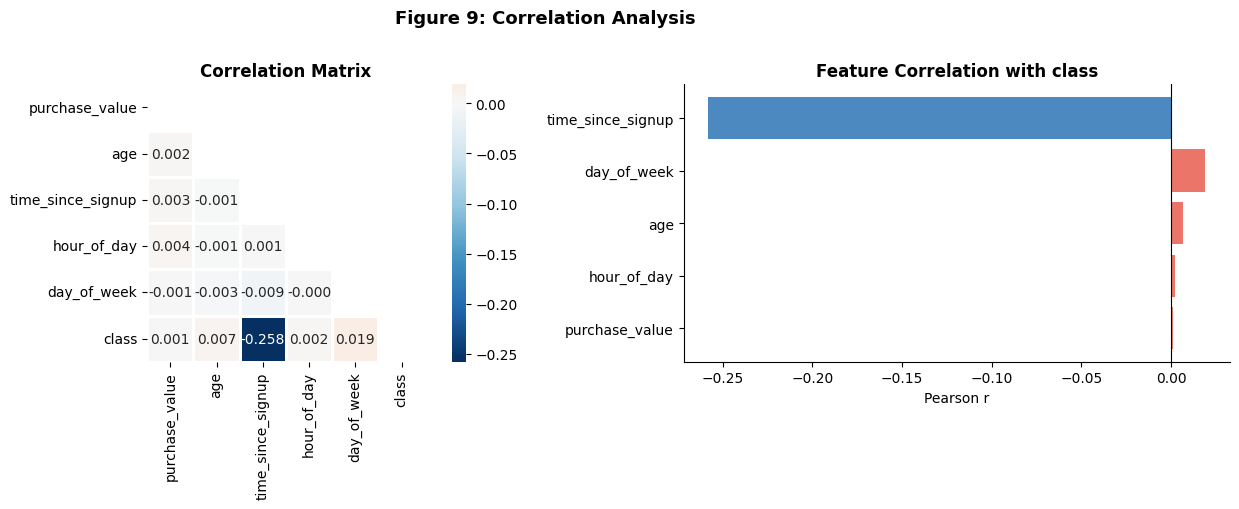

In [42]:
num_cols = ['purchase_value', 'age', 'time_since_signup', 'hour_of_day', 'day_of_week', 'class']
corr = df[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

import matplotlib
mask = np.triu(np.ones_like(corr, dtype=bool))
import seaborn as sns
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=1, ax=axes[0],
            annot_kws={'size': 10})
axes[0].set_title('Correlation Matrix', fontweight='bold')

target_corr = corr['class'].drop('class').sort_values(key=abs, ascending=True)
colors_bar = [CORAL if v > 0 else BLUE for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors_bar, alpha=0.85, edgecolor='none')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Feature Correlation with class', fontweight='bold')
axes[1].set_xlabel('Pearson r')

plt.suptitle('Figure 9: Correlation Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/figures/fig9_correlation_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Missing Value & Duplicate Analysis

In [43]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values.')

print()
print('=== Duplicates ===')
n_dup = df.duplicated().sum()
print(f'Fully duplicate rows: {n_dup}')

print()
print('=== Outliers — purchase_value ===')
Q1, Q3 = df['purchase_value'].quantile([0.25, 0.75])
IQR = Q3 - Q1
n_out = ((df['purchase_value'] < Q1-1.5*IQR) | (df['purchase_value'] > Q3+1.5*IQR)).sum()
print(f'IQR outliers: {n_out:,} ({n_out/len(df)*100:.2f}%)')

=== Missing Values ===
No missing values.

=== Duplicates ===
Fully duplicate rows: 0

=== Outliers — purchase_value ===
IQR outliers: 1,067 (0.71%)


---
## 10. Top EDA Insights

### Insight 1 — Class Imbalance (~9.4% fraud)
The dataset is imbalanced at roughly 90.6% legitimate vs 9.4% fraud. This is less extreme than the credit card dataset but still requires class-weight adjustment or SMOTE during training. Standard accuracy will be misleading — Precision-Recall AUC and F1 are the correct evaluation metrics.

### Insight 2 — time_since_signup is the Strongest Fraud Signal
Accounts that transact within 1 hour of signup have a substantially higher fraud rate than older accounts. This feature alone provides strong discriminatory power and must be included in all models. Very short signup-to-purchase gaps (< 300 seconds) are especially suspicious.

### Insight 3 — Temporal Patterns Cluster at Night / Early Morning
Fraud rate peaks between 00:00 and 04:00. This aligns with known fraud patterns where attackers operate during off-peak hours when fraud monitoring is reduced. `hour_of_day` is an important engineered feature.

### Insight 4 — Browser and Source Are Weak Individual Predictors
Fraud rate variation across browsers and traffic sources is modest. However, these features may carry interaction effects — e.g., a specific browser + new account + night-time combination may be highly predictive even when each factor alone is weak.

### Insight 5 — Geolocation Adds Risk Signal
IP-to-country enrichment identifies 138 unique countries. Several countries show materially elevated fraud rates. `country_encoded` should be included as a feature, with the caveat that it requires ongoing monitoring as fraud geography shifts over time.